For CTGAN

In [8]:
from datetime import datetime
import numpy as np
import pandas as pd
from sklearn.utils import shuffle
from matplotlib.font_manager import FontProperties
from collections import Counter
import matplotlib.pyplot as plt
from imblearn.over_sampling import BorderlineSMOTE
from sklearn.preprocessing import LabelEncoder

In [5]:
base_path = r"..\..\Data\2.Data_transposed\\"

In [9]:
# Data loading
print("started...")
start_time = datetime.now()
num_samples = 1000000

data_tomato_healthy = pd.read_excel(base_path + "tomato_healthy.xlsx", sheet_name='Sheet1', engine='openpyxl')[:num_samples]
data_tomato_unhealthy = pd.read_excel(base_path + "tomato_Unhealthy.xlsx", sheet_name='Sheet1', engine='openpyxl')[:num_samples]
data_potato = pd.read_excel(base_path + "potato.xlsx", sheet_name='Sheet1', engine='openpyxl')[:num_samples]
data_chilli = pd.read_excel(base_path + "chilli.xlsx", sheet_name='Sheet1', engine='openpyxl').sample(frac = 1)[:num_samples]
data_capsicum = pd.read_excel(base_path + "capsicum.xlsx", sheet_name='Sheet1', engine='openpyxl').sample(frac = 1)[:num_samples]
data_mulberry = pd.read_excel(base_path + "mulberry.xlsx", sheet_name='Sheet1', engine='openpyxl').sample(frac = 1)[:num_samples]

end_time = datetime.now()
print('Data loading time is:> {}'.format(end_time - start_time))

started...
Data loading time is:> 0:00:41.470897


In [10]:
# Data shapes
print("Tomato healthy:", data_tomato_healthy.shape)
print("Tomato unhealthy:", data_tomato_unhealthy.shape)
print("potato:", data_potato.shape)
print("Chilli:", data_chilli.shape)
print("Capsicum:", data_capsicum.shape)
print("Mulberry:", data_mulberry.shape)

# Data Concatenating
df = pd.concat([data_tomato_healthy, data_tomato_unhealthy, data_potato, data_chilli, data_capsicum, data_mulberry], axis = 0)
df_final=df.copy()
df_final

Tomato healthy: (2670, 944)
Tomato unhealthy: (274, 944)
potato: (770, 944)
Chilli: (125, 944)
Capsicum: (75, 944)
Mulberry: (150, 944)


,label,400,401,402,403,404,405,406,407,408,...,1333,1334,1335,1336,1337,1338,1339,1340,1341,1342
0,tomato_healthy,0.008590,0.008290,0.006470,0.005260,0.010600,0.013100,0.012600,0.011900,0.014300,...,0.034100,0.033800,0.033300,0.032700,0.032378,0.032500,0.032000,0.031000,0.030800,0.030600
1,tomato_healthy,0.016800,0.019900,0.021000,0.019600,0.021500,0.021200,0.019200,0.017600,0.017400,...,0.041700,0.041000,0.040400,0.038667,0.037700,0.037700,0.037500,0.036800,0.036000,0.035800
2,tomato_healthy,0.017200,0.017200,0.015400,0.013800,0.015400,0.014800,0.013900,0.015000,0.015636,...,0.029936,0.030500,0.030000,0.029100,0.028700,0.028400,0.027800,0.027900,0.027000,0.022900
3,tomato_healthy,0.017800,0.019100,0.023800,0.025300,0.022220,0.024600,0.027700,0.026100,0.029300,...,0.283379,0.282930,0.281796,0.281533,0.279989,0.276878,0.275332,0.274354,0.272459,0.269984
4,tomato_healthy,0.018700,0.018600,0.019100,0.020400,0.020800,0.020100,0.020600,0.022723,0.018100,...,0.042100,0.041500,0.040800,0.040100,0.039700,0.039800,0.039300,0.038595,0.038288,0.037600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,mulberry,0.039225,0.037105,0.037137,0.039161,0.036211,0.036792,0.038634,0.037865,0.036737,...,0.408826,0.407575,0.406125,0.408425,0.407359,0.400932,0.399482,0.401902,0.401227,0.400289
91,mulberry,0.070162,0.069256,0.071211,0.074198,0.066954,0.067906,0.071515,0.069412,0.070239,...,0.485922,0.485471,0.483521,0.483565,0.481453,0.474760,0.472705,0.474392,0.472482,0.469241
81,mulberry,0.058208,0.062704,0.063189,0.057404,0.057262,0.058511,0.059230,0.058820,0.060161,...,0.484744,0.483750,0.481802,0.479299,0.476675,0.473107,0.471866,0.472289,0.470632,0.469765
19,mulberry,0.353331,0.354678,0.355816,0.355932,0.352388,0.345510,0.345138,0.356007,0.353188,...,0.463415,0.460664,0.461012,0.462893,0.462546,0.462688,0.462683,0.460007,0.458580,0.458669


In [12]:
# Loading CTGAN Syntetic data

base_path = r"..\..\Data\6.CTGAN\\"

In [13]:
# Data loading
print("started...")
start_time = datetime.now()
num_samples = 1000000

data_tomato_healthy = pd.read_excel(base_path + "tomato_healthy.xlsx", sheet_name='Sheet1', engine='openpyxl')[:num_samples]
data_tomato_unhealthy = pd.read_excel(base_path + "tomato_Unhealthy.xlsx", sheet_name='Sheet1', engine='openpyxl')[:num_samples]
data_potato = pd.read_excel(base_path + "potato.xlsx", sheet_name='Sheet1', engine='openpyxl')[:num_samples]
data_chilli = pd.read_excel(base_path + "chilli.xlsx", sheet_name='Sheet1', engine='openpyxl').sample(frac = 1)[:num_samples]
data_capsicum = pd.read_excel(base_path + "capsicum.xlsx", sheet_name='Sheet1', engine='openpyxl').sample(frac = 1)[:num_samples]
data_mulberry = pd.read_excel(base_path + "mulberry.xlsx", sheet_name='Sheet1', engine='openpyxl').sample(frac = 1)[:num_samples]

end_time = datetime.now()
print('Data loading time is:> {}'.format(end_time - start_time))

started...
Data loading time is:> 0:02:00.956711


In [14]:
# Data shapes
print("Tomato healthy:", data_tomato_healthy.shape)
print("Tomato unhealthy:", data_tomato_unhealthy.shape)
print("potato:", data_potato.shape)
print("Chilli:", data_chilli.shape)
print("Capsicum:", data_capsicum.shape)
print("Mulberry:", data_mulberry.shape)

# Data Concatenating
df = pd.concat([data_tomato_healthy, data_tomato_unhealthy, data_potato, data_chilli, data_capsicum, data_mulberry], axis = 0)
resampled_df = df.copy()
resampled_df

Tomato healthy: (2000, 944)
Tomato unhealthy: (2000, 944)
potato: (2000, 944)
Chilli: (2000, 944)
Capsicum: (2000, 944)
Mulberry: (2000, 944)


,label,400,401,402,403,404,405,406,407,408,...,1333,1334,1335,1336,1337,1338,1339,1340,1341,1342
0,tomato_healthy,0.138972,0.016344,0.138795,0.049644,0.052266,0.152917,0.158692,0.095327,0.117389,...,0.606563,0.614576,0.613708,0.632161,0.594877,0.672311,0.429077,0.407841,0.544141,0.468188
1,tomato_healthy,0.171192,0.181880,0.221681,0.233427,0.125908,0.160690,0.076840,0.055193,0.157884,...,0.531379,0.601908,0.628321,0.365396,2.023702,0.172755,0.443070,0.499728,0.756050,0.407090
2,tomato_healthy,0.110863,0.097994,0.205451,0.128950,0.075854,0.144014,0.100693,0.041892,0.097151,...,0.353142,0.644193,0.526600,0.577565,0.594370,0.640661,0.315305,0.582624,0.153632,0.498390
3,tomato_healthy,0.487878,0.139976,0.097271,0.825983,0.318907,0.696993,0.471629,0.258890,0.769886,...,0.107992,0.578199,0.352164,0.223537,0.103502,0.180577,-0.000902,0.037411,0.373190,0.134743
4,tomato_healthy,0.124985,0.165105,0.156813,0.127390,0.136653,0.241286,0.323916,0.160003,0.216548,...,0.010226,0.595462,0.411318,0.516202,0.817295,0.450727,0.111233,0.470033,0.707103,0.495774
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,mulberry,0.030109,0.158790,0.177242,0.288822,0.020046,0.529362,0.099182,0.250770,0.294139,...,0.581616,0.548981,0.731535,0.482320,0.528515,0.430821,0.406578,0.521749,0.558526,0.514091
805,mulberry,0.015847,0.044600,0.061737,0.107778,0.127218,0.185549,0.221505,0.337580,0.174479,...,0.465273,0.596016,0.505254,0.603094,0.497025,0.746947,0.415954,0.573082,0.559002,0.352735
1221,mulberry,0.170189,0.161554,0.073742,0.407938,0.033057,0.334468,0.376611,0.218028,0.166217,...,0.478418,0.321391,0.644984,1.099073,0.389394,1.088786,0.414220,0.455844,0.825871,0.572201
34,mulberry,0.183697,0.188793,0.305531,0.080617,0.020046,0.212599,0.260847,0.046352,0.135070,...,0.439151,0.373804,0.670430,0.712116,0.330239,0.807922,0.562084,0.377487,0.656666,0.490488


In [15]:
from common_fun import create_data, apply_pca, apply_TSNE, apply_UMAP, plot_3D, plot_3D_static

tomato_unhealthy real data shape: (274, 944)
tomato_unhealthy synthetic data shape: (2000, 944)


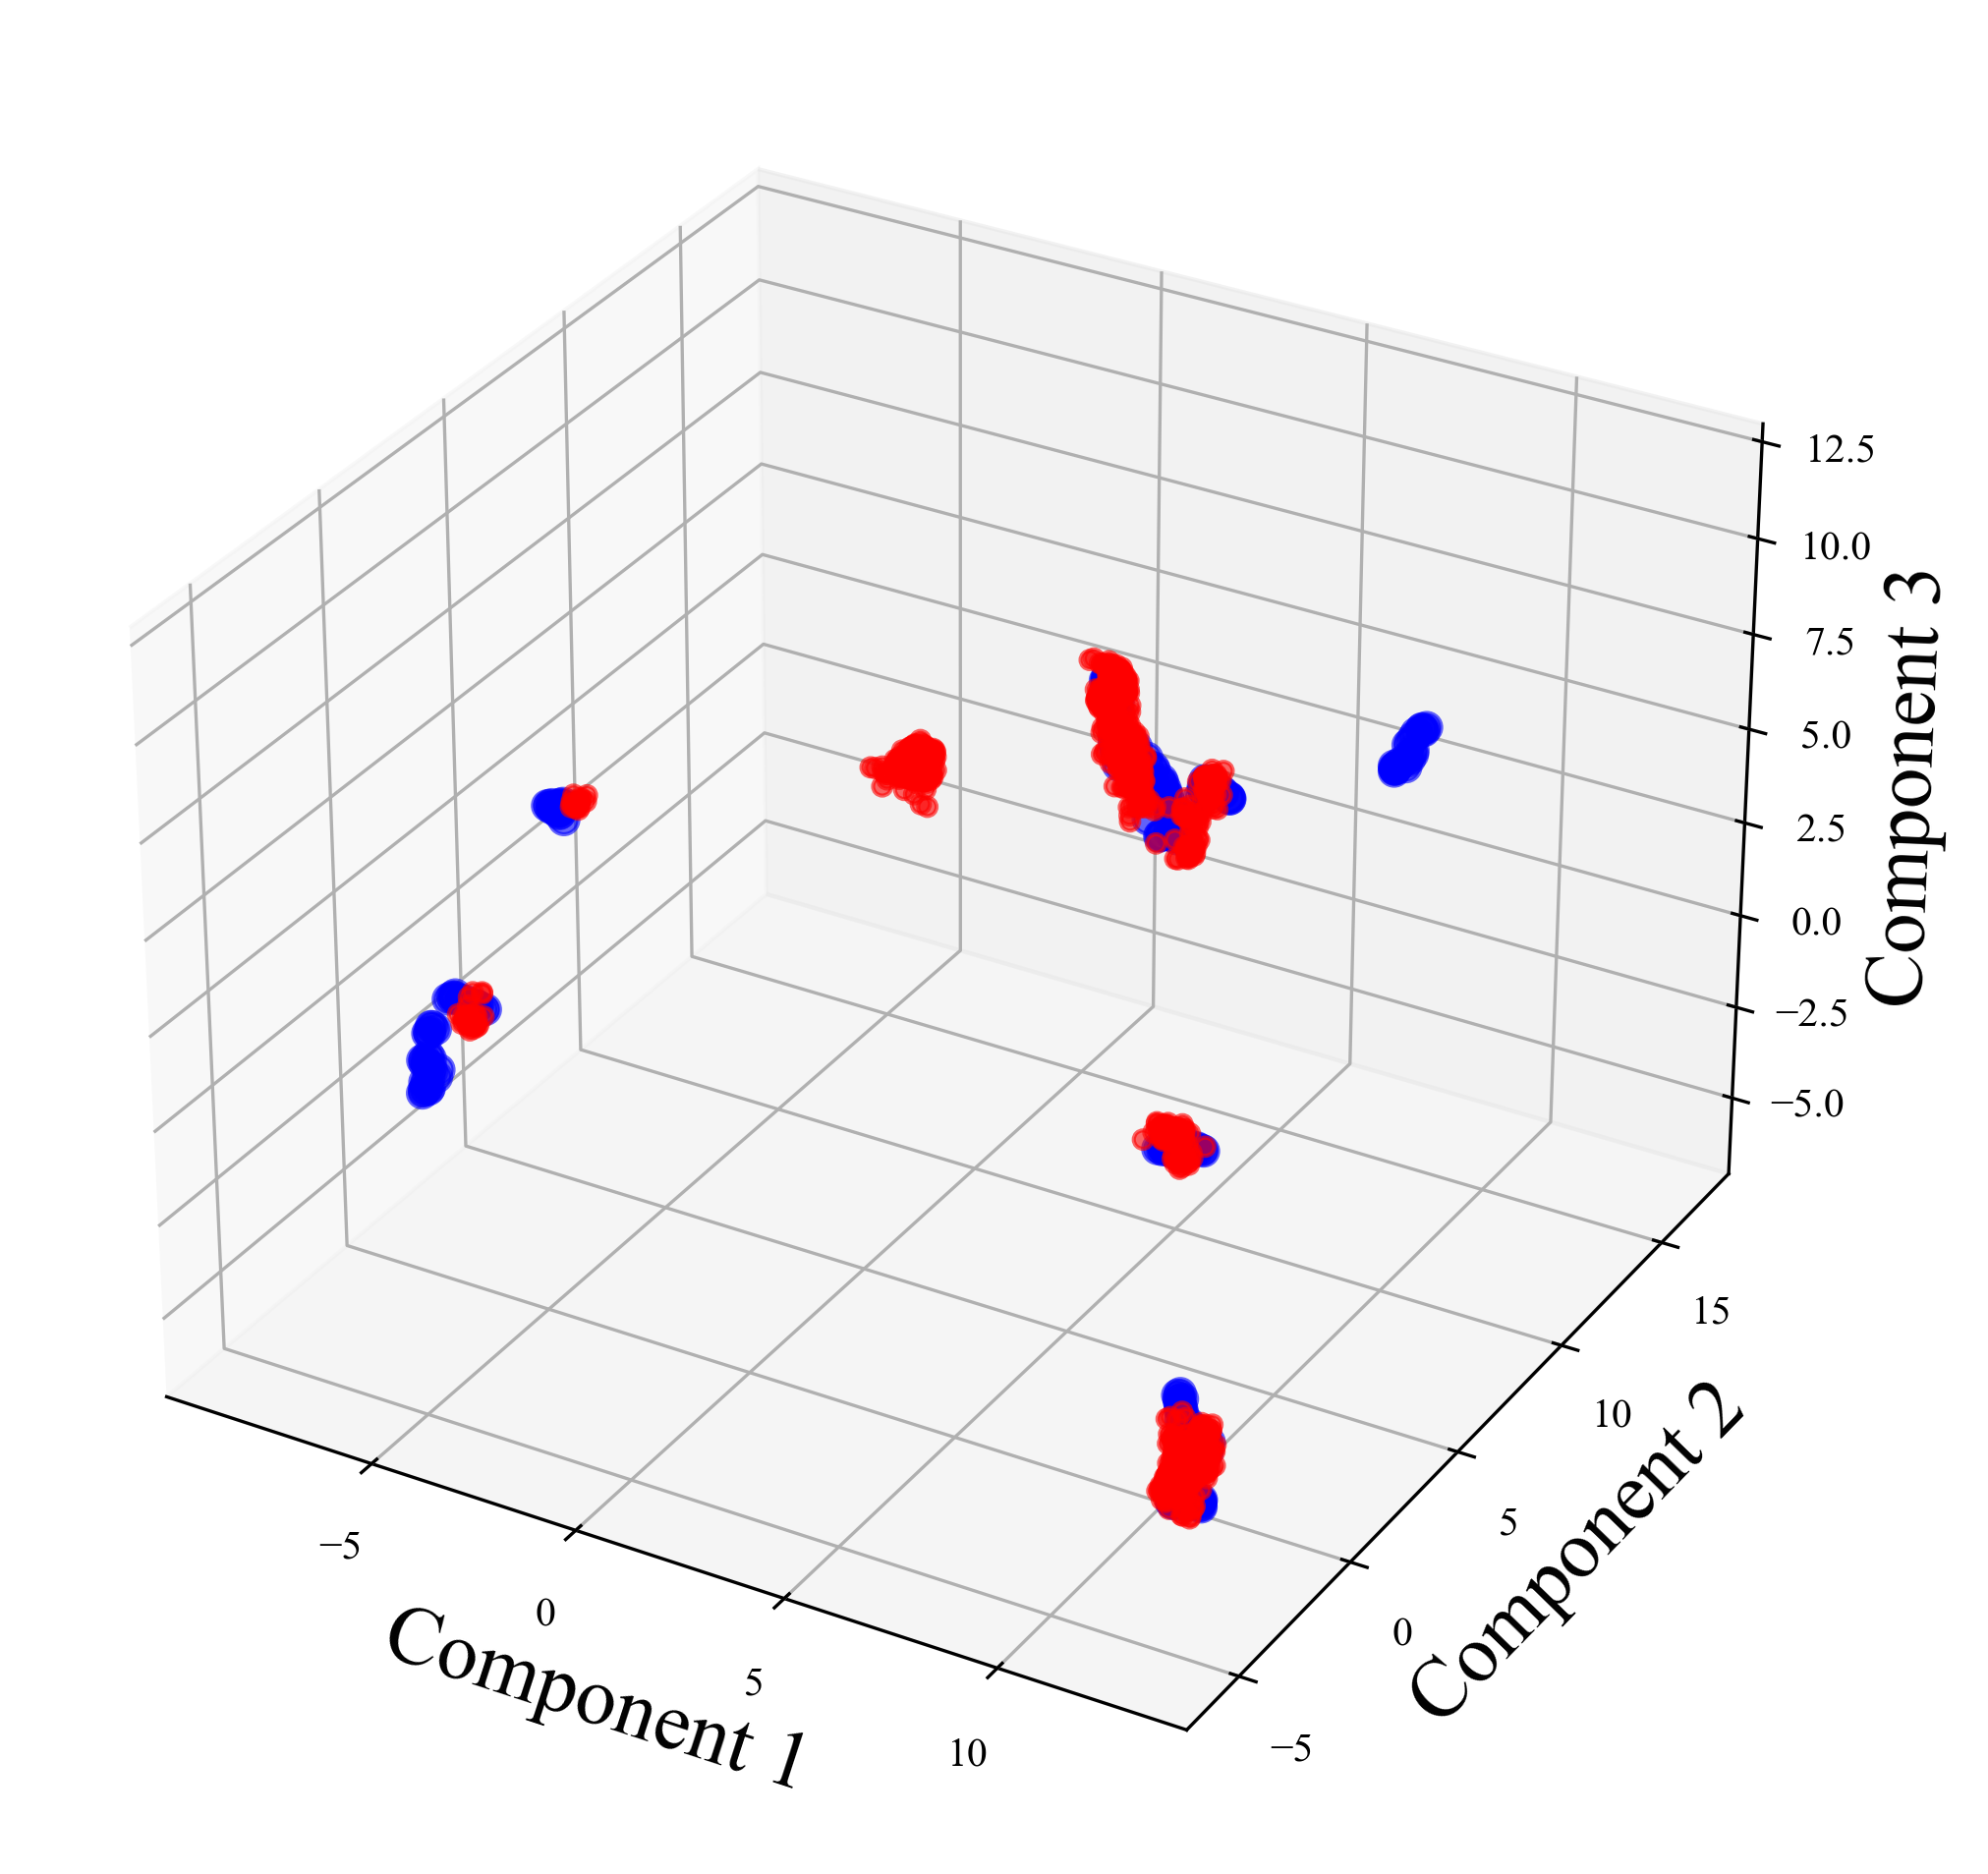

In [21]:
# tomato_healthy, tomato_unhealthy, chilli, potato, capsicum, mulberry
crop_name = "tomato_unhealthy" #capsicum, chilli, mulberry, potato, tomato_healthy, tomato_unhealthy
X_real_scaled, X_synthetic_scaled = create_data(crop_name, df_final, resampled_df)

# plot_df = apply_pca(X_real_scaled, X_synthetic_scaled)
# plot_3D(crop_name, plot_df, ptype="PCA")

# plot_df = apply_TSNE(X_real_scaled, X_synthetic_scaled)
# plot_3D(crop_name, plot_df, ptype="TSNE")

plot_df = apply_UMAP(X_real_scaled, X_synthetic_scaled)
plot_3D_static(crop_name, plot_df, ptype="UMAP")